Duomenų įkėlimas iš Kaggle svetainės.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("samuelcortinhas/muffin-vs-chihuahua-image-classification")

print("Path to dataset files:", path)

import os

print(os.listdir(path))

Using Colab cache for faster access to the 'muffin-vs-chihuahua-image-classification' dataset.
Path to dataset files: /kaggle/input/muffin-vs-chihuahua-image-classification
['test', 'train']


Sukuriam naujus aplankus ir apjungiam test su train duomenimis.

In [2]:
import shutil
import os

train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test')
combined_dir = '/kaggle/working/all_data'

os.makedirs(combined_dir, exist_ok=True)

# Sukuriam klasių aplankus
for class_name in os.listdir(train_dir):
    os.makedirs(os.path.join(combined_dir, class_name), exist_ok=True)

# Perkopijuojam visus train
for class_name in os.listdir(train_dir):
    src = os.path.join(train_dir, class_name)
    dst = os.path.join(combined_dir, class_name)
    for file in os.listdir(src):
        shutil.copy(os.path.join(src, file), os.path.join(dst, file))

# Perkopijuojam visus test
for class_name in os.listdir(test_dir):
    src = os.path.join(test_dir, class_name)
    dst = os.path.join(combined_dir, class_name)
    for file in os.listdir(src):
        shutil.copy(os.path.join(src, file), os.path.join(dst, file))

print("Visi failai sujungti į:", combined_dir)

Visi failai sujungti į: /kaggle/working/all_data


Daliname duomenis į mokymo, validavimo ir testavimo aibes (80:10:10).

3 aplankai su 2 aplankais viduje (chihuahua ir muffin).

data_split/

 ├── train/
 │   ├── muffin/
 │   ├── chihuahua/

 ├── val/
 │   ├── muffin/
 │   ├── chihuahua/

 └── test/
     ├── muffin/
     ├── chihuahua/

In [3]:
!pip install split-folders

import splitfolders

# Dalinam 80:10:10
splitfolders.ratio(
    combined_dir,
    output="/kaggle/working/data_split",
    seed=42,
    ratio=(.8, .1, .1)
)


base_dir = "/kaggle/working/data_split"
total_counts = {}

for split in ['train', 'val', 'test']:
    split_path = os.path.join(base_dir, split)
    print(f"\n {split.upper()}:")

    # kiekvienai klasei
    split_total = 0
    for class_name in sorted(os.listdir(split_path)):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            num_images = len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])
            print(f"  {class_name}: {num_images} paveikslėlių")
            split_total += num_images

    total_counts[split] = split_total
    print(f"Iš viso {split}: {split_total} paveikslėlių")



Copying files: 5917 files [00:01, 4320.64 files/s]



 TRAIN:
  chihuahua: 2559 paveikslėlių
  muffin: 2174 paveikslėlių
Iš viso train: 4733 paveikslėlių

 VAL:
  chihuahua: 319 paveikslėlių
  muffin: 271 paveikslėlių
Iš viso val: 590 paveikslėlių

 TEST:
  chihuahua: 321 paveikslėlių
  muffin: 273 paveikslėlių
Iš viso test: 594 paveikslėlių


Įkeliame reikalingas bibliotekas.

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import matplotlib.pyplot as plt

**Duomenų paruošimas**

Sukuriama duomenų generavimo funkcija.

Suskirstoma automatiškai į klases, dėl ImageDataGenerator - chihuahua klasė 0, muffin klasė 1.

* target_size=(150,150) → kiekviena nuotrauka paverčiama į formą (150,150,3)

* rescale=1./255 → pikselių reikšmės normalizuojamos į [0,1] intervalą

* Iš to gaunami du numpy masyvai: (X_batch, y_batch)

Modelis gauna nuotraukas, paverstas į normalizuotus RGB pikselių masyvus.




In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def create_generators(class_mode, batch_size, img_size=(150,150)):
    datagen = ImageDataGenerator(rescale=1./255)

    train_gen = datagen.flow_from_directory(
        '/kaggle/working/data_split/train/',
        target_size=img_size,
        batch_size=batch_size,
        class_mode=class_mode
    )
    val_gen = datagen.flow_from_directory(
        '/kaggle/working/data_split/val/',
        target_size=img_size,
        batch_size=batch_size,
        class_mode=class_mode
    )
    test_gen = datagen.flow_from_directory(
        '/kaggle/working/data_split/test/',
        target_size=img_size,
        batch_size=batch_size,
        class_mode=class_mode,
        shuffle=False
    )


    return train_gen, val_gen, test_gen


Generuojame duomenų aibes.

In [8]:
train_gen, val_gen, test_gen = create_generators(class_mode='binary', batch_size=32)

Found 4733 images belonging to 2 classes.
Found 590 images belonging to 2 classes.
Found 594 images belonging to 2 classes.


**Modelio mokymo funkcija**

In [6]:
def train_model(model, train_gen, val_gen, epochs):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs
    )
    return history


**Skirtingos architektūros:**


  Modelis simple

In [ ]:
model1 = models.Sequential()
model1.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model1.add(layers.Flatten())
model1.add(layers.Dense(1, activation='sigmoid'))

model1.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history1 = train_model(model1, train_gen, val_gen, epochs=10)


Modelis medium

In [ ]:
model2 = models.Sequential()
model2.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model2.add(layers.MaxPooling2D((2, 2)))
model2.add(layers.Conv2D(64, (3, 3), activation='relu'))
model2.add(layers.MaxPooling2D((2, 2)))
model2.add(layers.Flatten())
model2.add(layers.Dense(128, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))


model2.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history2 = train_model(model2, train_gen, val_gen, epochs=10)

Modelis deep

In [12]:
model3 = models.Sequential()
model3.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model3.add(layers.MaxPooling2D((2, 2)))
model3.add(layers.Conv2D(64, (3, 3), activation='relu'))
model3.add(layers.MaxPooling2D((2, 2)))
model3.add(layers.Conv2D(128, (3, 3), activation='relu'))
model3.add(layers.Conv2D(256, (3, 3), activation='relu'))
model3.add(layers.MaxPooling2D((2, 2)))
model3.add(layers.Flatten())
model3.add(layers.Dense(512, activation='relu'))
model3.add(layers.Dense(1, activation='sigmoid'))

model3.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history3 = train_model(model3, train_gen, val_gen, epochs=10)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 39s 216ms/step - accuracy: 0.6668 - loss: 0.7318 - val_accuracy: 0.8153 - val_loss: 0.4522
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 172ms/step - accuracy: 0.8294 - loss: 0.4032 - val_accuracy: 0.8000 - val_loss: 0.4317
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 176ms/step - accuracy: 0.8514 - loss: 0.3398 - val_accuracy: 0.8119 - val_loss: 0.4080
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 29s 193ms/step - accuracy: 0.8714 - loss: 0.3037 - val_accuracy: 0.8644 - val_loss: 0.3237
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 176ms/step - accuracy: 0.8979 - loss: 0.2484 - val_accuracy: 0.8983 - val_loss: 0.2574
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 172ms/step - accuracy: 0.9205 - loss: 0.2043 - val_accuracy: 0.9034 - val_loss: 0.2560
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 173ms/step - accuracy: 0.9357 - loss: 0.1666 - val_accuracy: 0.9237 - val_loss: 0.2572
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 174ms/step - accuracy: 0.9539 - loss: 0

Treniruojam visus 3 modelius

Brėžiam jiems grafikus

In [ ]:
history = [history1, history2, history3]
for i in range(3):
    plt.figure()
    plt.plot(history[i].history['accuracy'], label='Mokymo')
    plt.plot(history[i].history['val_accuracy'], label='Validavimo')
    plt.xlabel('Epocha')
    plt.ylabel('Tikslumas')
    plt.ylim([0.5, 1])
    plt.xlim([-0.5, 9.5])
    plt.title(f"Modelis {i+1}")
    plt.legend(loc='lower right')
    plt.show()

In [ ]:
for i in range(3):
    plt.figure()
    plt.plot(history[i].history['loss'], label='Mokymo')
    plt.plot(history[i].history['val_loss'], label='Validavimo')
    plt.xlabel('Epocha')
    plt.ylabel('Paklaida')
    plt.ylim([0, 1.2])
    plt.xlim([-0.5, 9.5])
    plt.title(f"Modelis {i+1}")
    plt.legend(loc='lower left')
    plt.show()

*Funkcija hiperparametrų keitimui*

Funkcija sukurta pagal trečiąją modelio architektūrą.

In [12]:
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam, SGD, Adagrad, RMSprop

def create_model3(
    conv_filters,
    activation,
    kernel_sizes,
    pool_sizes,
    dense_neurons,
    dropout_rates,       # naujas parametras: lista su Dropout tikimybėmis kiekvienam sluoksniui
    optimizer_type,
    learning_rate,
    loss_type,
    use_batchnorm,
    input_shape=(150,150,3)
):
    model = models.Sequential()

    # Pirmas konvoliucijos sluoksnis
    model.add(layers.Conv2D(conv_filters[0], kernel_sizes[0], padding='same', input_shape=input_shape))
    if use_batchnorm:
        model.add(layers.BatchNormalization())
    model.add(layers.Activation(activation))
    model.add(layers.MaxPooling2D(pool_size=pool_sizes[0]))
    if dropout_rates[0] > 0:
        model.add(layers.Dropout(dropout_rates[0]))

    # Likę konvoliucijos sluoksniai
    for i in range(1, len(conv_filters)):
        model.add(layers.Conv2D(conv_filters[i], kernel_sizes[i], padding='same'))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))
        if i-1 < len(pool_sizes):
            model.add(layers.MaxPooling2D(pool_size=pool_sizes[i-1]))
        if dropout_rates[i] > 0:
            model.add(layers.Dropout(dropout_rates[i]))

    model.add(layers.Flatten())

    # pilnai sujungti sluoksniai
    for j, neurons in enumerate(dense_neurons):
        model.add(layers.Dense(neurons))
        if use_batchnorm:
            model.add(layers.BatchNormalization())
        model.add(layers.Activation(activation))
        if dropout_rates[len(conv_filters)+j] > 0:
            model.add(layers.Dropout(dropout_rates[len(conv_filters)+j]))

    # Išėjimo sluoksnis
    model.add(layers.Dense(1, activation='sigmoid'))

    optimizer_type = optimizer_type.lower()
    if optimizer_type == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_type == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer_type == 'adagrad':
        opt = Adagrad(learning_rate=learning_rate)
    elif optimizer_type == 'rmsprop':
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss=loss_type, metrics=['accuracy'])

    return model


**Funkcija grafikų braižymui**

In [10]:
def grafikai(history):
  plt.figure()
  plt.plot(history.history['loss'], label='Mokymo')
  plt.plot(history.history['val_loss'], label='Validavimo')
  plt.xlabel('Epocha')
  plt.ylabel('Paklaida')
  plt.xlim([-0.5, 9.5])
  plt.legend(loc='lower left')
  plt.show()

  plt.figure()
  plt.plot(history.history['accuracy'], label='Mokymo')
  plt.plot(history.history['val_accuracy'], label='Validavimo')
  plt.xlabel('Epocha')
  plt.ylabel('Tikslumas')
  plt.ylim([0, 1])
  plt.xlim([-0.5, 9.5])
  plt.legend(loc='lower right')
  plt.show()

Pridedame vieną išmetimo (dropout) sluoksnį po pirmo konvoliucijos sluoksnio ir vieną  po pilnai sujungto (dense) sluoksnio.

Keičiame jų tikimybes: 0.3, 0.6, 0.9.

Brėžiame grafikus kiekvienam tinklo modeliui.

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 35s 197ms/step - accuracy: 0.5428 - loss: 0.7687 - val_accuracy: 0.6915 - val_loss: 0.5794
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 33s 170ms/step - accuracy: 0.7952 - loss: 0.4427 - val_accuracy: 0.8339 - val_loss: 0.3622
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 172ms/step - accuracy: 0.8542 - loss: 0.3509 - val_accuracy: 0.8780 - val_loss: 0.3103
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 170ms/step - accuracy: 0.8770 - loss: 0.2990 - val_accuracy: 0.8424 - val_loss: 0.3590
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 175ms/step - accuracy: 0.8749 - loss: 0.2949 - val_accuracy: 0.8864 - val_loss: 0.2768
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 168ms/step - accuracy: 0.8985 - loss: 0.2537 - val_accuracy: 0.8966 - val_loss: 0.2571
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 171ms/step - accuracy: 0.9124 - loss: 0.2251 - val_accuracy: 0.8966 - val_loss: 0.2301
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 170ms/step - accuracy: 0.9333 - loss: 0

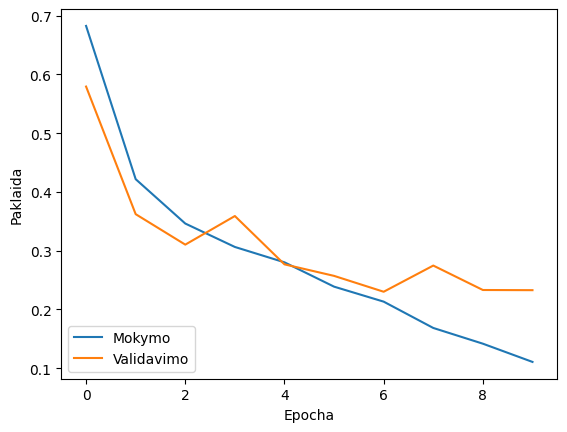

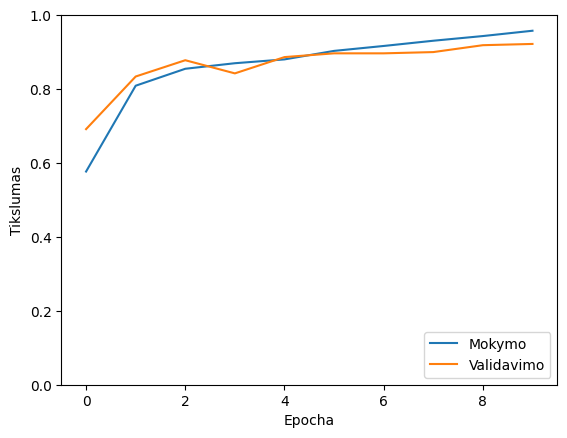

In [14]:

m1 = create_model3(
    conv_filters=[32, 64, 128, 256],
    activation='relu',
    kernel_sizes=[(3,3), (3,3), (3, 3), (3, 3)],
    pool_sizes=[(2,2), (2,2), (2,2)],
    dense_neurons=[512],
    dropout_rates=[0.3, 0, 0, 0, 0.3],
    optimizer_type='adam',
    learning_rate=0.001,
    loss_type='binary_crossentropy',
    use_batchnorm=False,
    input_shape=(150,150,3)
)
h1 = train_model(m1, train_gen, val_gen, epochs=10)
grafikai(h1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 35s 206ms/step - accuracy: 0.5693 - loss: 0.8780 - val_accuracy: 0.7729 - val_loss: 0.5260
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 35s 186ms/step - accuracy: 0.8076 - loss: 0.4316 - val_accuracy: 0.8322 - val_loss: 0.3889
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 28s 191ms/step - accuracy: 0.8549 - loss: 0.3505 - val_accuracy: 0.8746 - val_loss: 0.3148
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 28s 187ms/step - accuracy: 0.8559 - loss: 0.3388 - val_accuracy: 0.8339 - val_loss: 0.3876
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 180ms/step - accuracy: 0.8820 - loss: 0.2941 - val_accuracy: 0.8678 - val_loss: 0.3313
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 180ms/step - accuracy: 0.8926 - loss: 0.2519 - val_accuracy: 0.8932 - val_loss: 0.2698
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 185ms/step - accuracy: 0.9052 - loss: 0.2303 - val_accuracy: 0.8949 - val_loss: 0.2507
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 30s 203ms/step - accuracy: 0.9147 - loss: 0

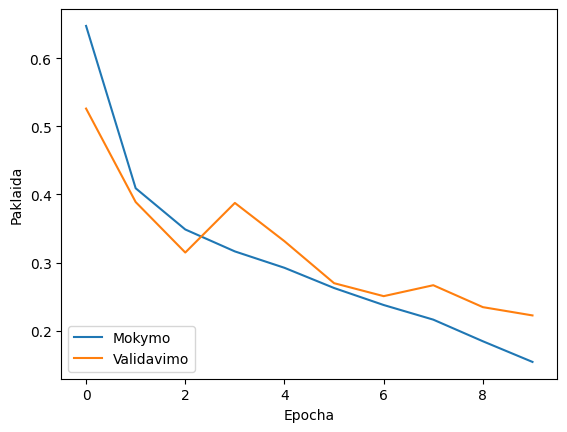

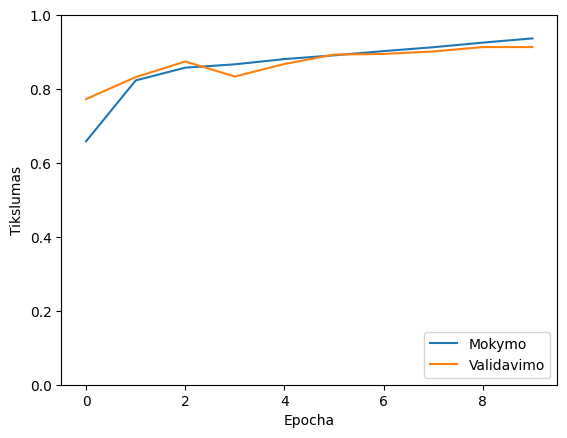

In [18]:
m2 = create_model3(
    conv_filters=[32, 64, 128, 256],
    activation='relu',
    kernel_sizes=[(3,3), (3,3), (3, 3), (3, 3)],
    pool_sizes=[(2,2), (2,2), (2,2)],
    dense_neurons=[512],
    dropout_rates=[0.6, 0, 0, 0, 0.6],
    optimizer_type='adam',
    learning_rate=0.001,
    loss_type='binary_crossentropy',
    use_batchnorm=False,
    input_shape=(150,150,3)
)
h2 = train_model(m2, train_gen, val_gen, epochs=10)
grafikai(h2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 33s 194ms/step - accuracy: 0.5189 - loss: 0.8423 - val_accuracy: 0.5407 - val_loss: 0.6907
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 166ms/step - accuracy: 0.6482 - loss: 0.6177 - val_accuracy: 0.5983 - val_loss: 0.8410
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 166ms/step - accuracy: 0.7891 - loss: 0.4607 - val_accuracy: 0.5864 - val_loss: 0.9906
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - accuracy: 0.8306 - loss: 0.3942 - val_accuracy: 0.5508 - val_loss: 1.3383
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - accuracy: 0.8492 - loss: 0.3700 - val_accuracy: 0.5881 - val_loss: 0.8235
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 165ms/step - accuracy: 0.8523 - loss: 0.3579 - val_accuracy: 0.5407 - val_loss: 1.2615
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 164ms/step - accuracy: 0.8608 - loss: 0.3414 - val_accuracy: 0.5407 - val_loss: 1.3889
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 165ms/step - accuracy: 0.8581 - loss: 0

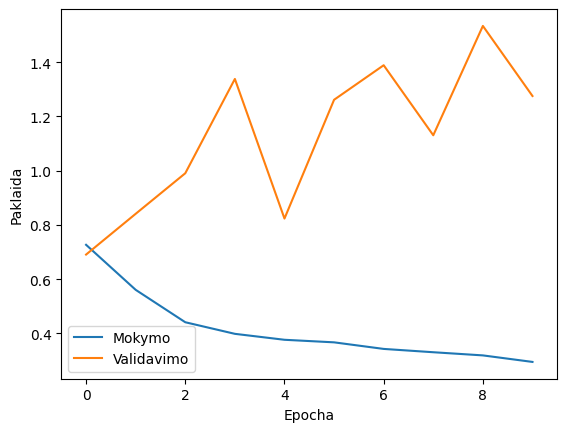

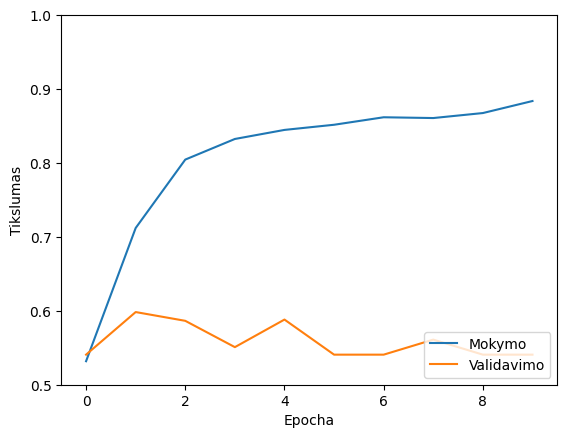

In [ ]:
m3 = create_model3(
    conv_filters=[32, 64, 128, 256],
    activation='relu',
    kernel_sizes=[(3,3), (3,3), (3, 3), (3, 3)],
    pool_sizes=[(2,2), (2,2), (2,2)],
    dense_neurons=[512],
    dropout_rates=[0.9, 0, 0, 0, 0.9],
    optimizer_type='adam',
    learning_rate=0.001,
    loss_type='binary_crossentropy',
    use_batchnorm=False,
    input_shape=(150,150,3)
)
h3 = train_model(m3, train_gen, val_gen, epochs=10)
grafikai(h3)

Pridedame paketų normalizavimą.

(Be normalizavimo, tai tiesiog m2 modelis).

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 51s 269ms/step - accuracy: 0.7580 - loss: 0.6722 - val_accuracy: 0.5407 - val_loss: 5.7158
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 28s 190ms/step - accuracy: 0.8457 - loss: 0.4241 - val_accuracy: 0.5407 - val_loss: 5.8740
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 181ms/step - accuracy: 0.8807 - loss: 0.3215 - val_accuracy: 0.5407 - val_loss: 4.5086
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 177ms/step - accuracy: 0.9035 - loss: 0.2520 - val_accuracy: 0.6068 - val_loss: 1.7514
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 179ms/step - accuracy: 0.9157 - loss: 0.2198 - val_accuracy: 0.8424 - val_loss: 0.3785
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 179ms/step - accuracy: 0.9270 - loss: 0.1960 - val_accuracy: 0.7339 - val_loss: 0.8527
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 27s 181ms/step - accuracy: 0.9221 - loss: 0.1993 - val_accuracy: 0.5407 - val_loss: 5.1997
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 28s 185ms/step - accuracy: 0.9158 - loss: 0

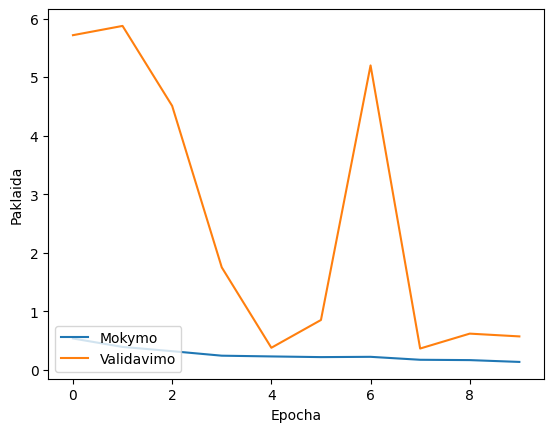

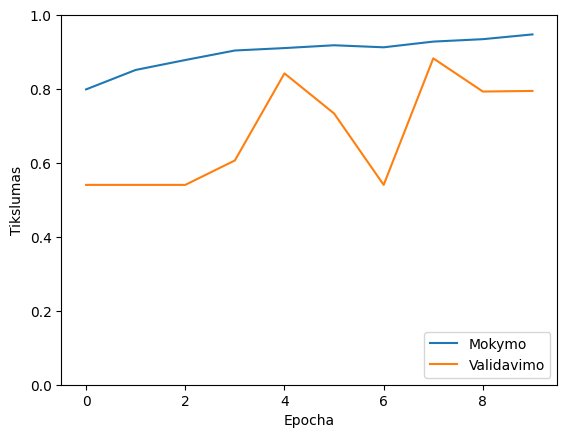

In [11]:
m4 = create_model3(
    conv_filters=[32, 64, 128, 256],
    activation='relu',
    kernel_sizes=[(3,3), (3,3), (3, 3), (3, 3)],
    pool_sizes=[(2,2), (2,2), (2,2)],
    dense_neurons=[512],
    dropout_rates=[0.6, 0, 0, 0, 0.6],
    optimizer_type='adam',
    learning_rate=0.001,
    loss_type='binary_crossentropy',
    use_batchnorm=True,
    input_shape=(150,150,3)
)
h4 = train_model(m4, train_gen, val_gen, epochs=10)
grafikai(h4)

Keičiam aktyvacijos funkcijas.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 33s 188ms/step - accuracy: 0.5240 - loss: 1.9718 - val_accuracy: 0.4593 - val_loss: 0.9419
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 169ms/step - accuracy: 0.5104 - loss: 0.8732 - val_accuracy: 0.4593 - val_loss: 0.8805
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - accuracy: 0.4920 - loss: 0.8267 - val_accuracy: 0.3932 - val_loss: 0.8010
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - accuracy: 0.5102 - loss: 0.7666 - val_accuracy: 0.3932 - val_loss: 0.7687
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 164ms/step - accuracy: 0.5203 - loss: 0.7331 - val_accuracy: 0.3864 - val_loss: 0.7545
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 164ms/step - accuracy: 0.5149 - loss: 0.7228 - val_accuracy: 0.5186 - val_loss: 0.7509
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 164ms/step - accuracy: 0.5130 - loss: 0.7272 - val_accuracy: 0.5339 - val_loss: 0.7187
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 167ms/step - accuracy: 0.5220 - loss: 0

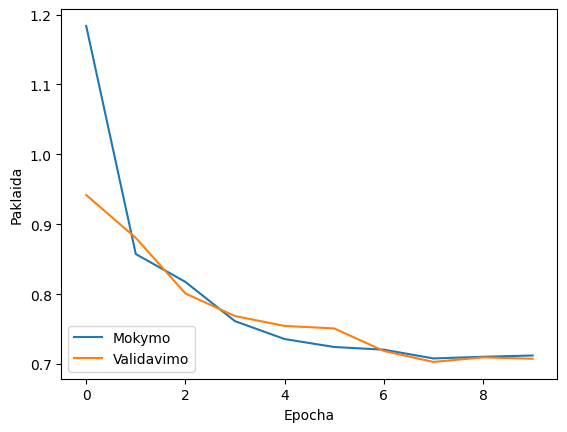

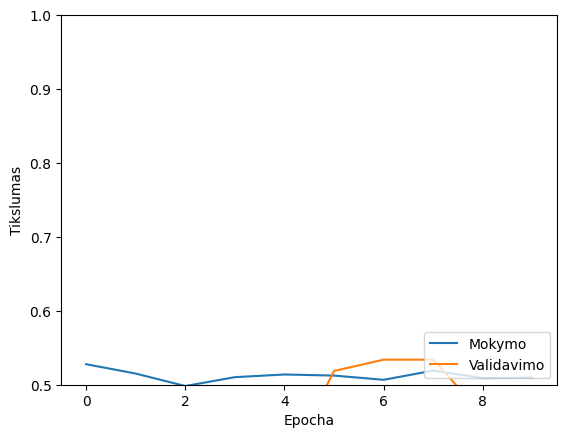

In [ ]:
m5 = create_model3(
    conv_filters=[32, 64, 128, 256],
    activation='tanh',
    kernel_sizes=[(3,3), (3,3), (3, 3,), (3, 3)],
    pool_sizes=[(2,2), (2,2), (2,2)],
    dense_neurons=[512],
    dropout_rates=[0.6, 0, 0, 0, 0.6],
    optimizer_type='adam',
    learning_rate=0.001,
    loss_type='binary_crossentropy',
    use_batchnorm=False,
    input_shape=(150,150,3)
)
h5 = train_model(m5, train_gen, val_gen, epochs=10)
grafikai(h5)

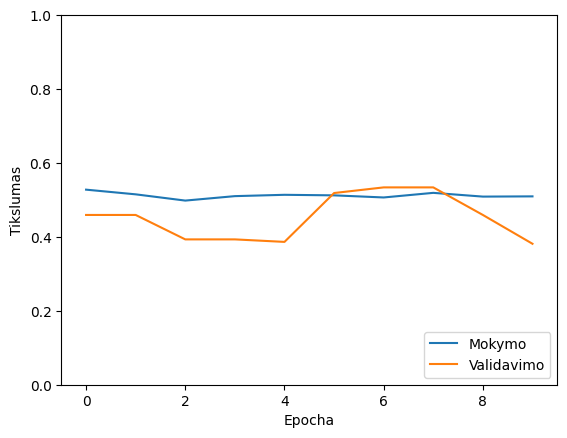

In [ ]:

plt.figure()
plt.plot(h5.history['accuracy'], label='Mokymo')
plt.plot(h5.history['val_accuracy'], label='Validavimo')
plt.xlabel('Epocha')
plt.ylabel('Tikslumas')
plt.ylim([0, 1])
plt.xlim([-0.5, 9.5])
plt.legend(loc='lower right')
plt.show()

LeakyReLu

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 33s 186ms/step - accuracy: 0.6161 - loss: 1.0106 - val_accuracy: 0.7847 - val_loss: 0.4976
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 164ms/step - accuracy: 0.8073 - loss: 0.4379 - val_accuracy: 0.8305 - val_loss: 0.4874
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 169ms/step - accuracy: 0.8615 - loss: 0.3409 - val_accuracy: 0.8000 - val_loss: 0.4907
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 162ms/step - accuracy: 0.8781 - loss: 0.2968 - val_accuracy: 0.6542 - val_loss: 1.3343
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 166ms/step - accuracy: 0.8890 - loss: 0.2644 - val_accuracy: 0.8119 - val_loss: 0.5413
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 166ms/step - accuracy: 0.9082 - loss: 0.2218 - val_accuracy: 0.8881 - val_loss: 0.2872
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 162ms/step - accuracy: 0.9244 - loss: 0.1915 - val_accuracy: 0.8983 - val_loss: 0.2840
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 161ms/step - accuracy: 0.9321 - loss: 0

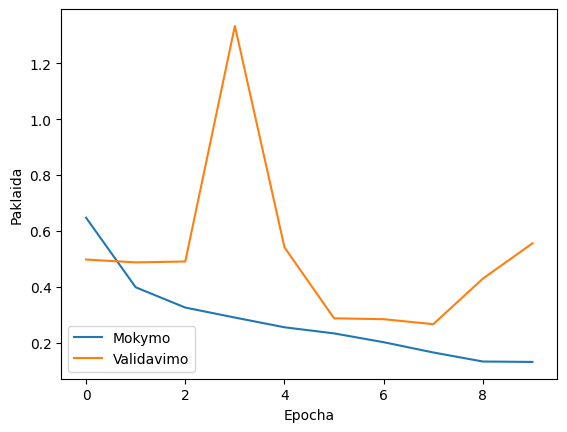

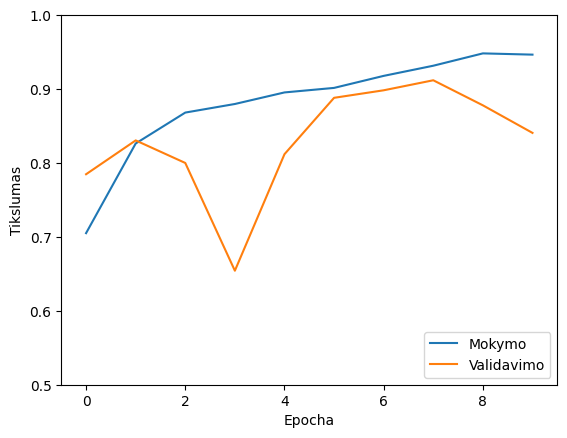

In [ ]:
m6 = create_model3(
    conv_filters=[32, 64, 128, 256],
    activation='leaky_relu',
    kernel_sizes=[(3,3), (3,3), (3, 3), (3, 3)],
    pool_sizes=[(2,2), (2,2), (2,2)],
    dense_neurons=[512],
    dropout_rates=[0.6, 0, 0, 0, 0.6],
    optimizer_type='adam',
    learning_rate=0.001,
    loss_type='binary_crossentropy',
    use_batchnorm=False,
    input_shape=(150,150,3)
)
h6 = train_model(m6, train_gen, val_gen, epochs=10)
grafikai(h6)

Softplus

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.5044 - loss: 524.7643 - val_accuracy: 0.5407 - val_loss: 0.7079
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 165ms/step - accuracy: 0.5045 - loss: 0.7813 - val_accuracy: 0.4593 - val_loss: 0.7107
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - accuracy: 0.4978 - loss: 0.7561 - val_accuracy: 0.5407 - val_loss: 0.6883
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 165ms/step - accuracy: 0.5109 - loss: 0.7558 - val_accuracy: 0.5407 - val_loss: 0.6979
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - accuracy: 0.5165 - loss: 0.7395 - val_accuracy: 0.4593 - val_loss: 0.7320
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 164ms/step - accuracy: 0.5086 - loss: 0.7828 - val_accuracy: 0.5661 - val_loss: 0.6858
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - accuracy: 0.5256 - loss: 0.8104 - val_accuracy: 0.5407 - val_loss: 0.6859
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 165ms/step - accuracy: 0.5340 - loss:

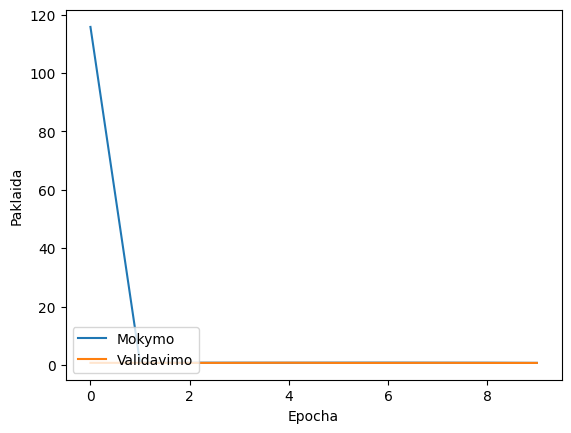

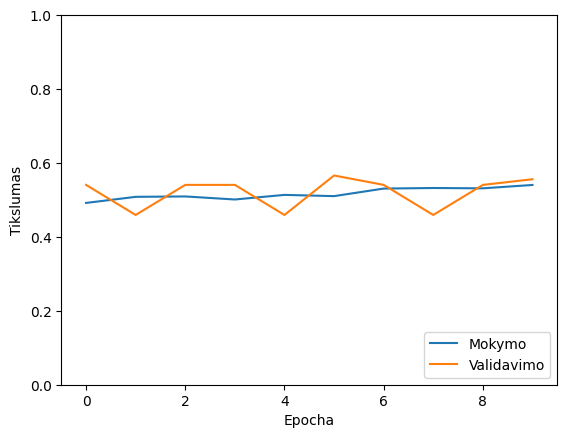

In [ ]:
m11 = create_model3(
    conv_filters=[32, 64, 128, 256],
    activation='softplus',
    kernel_sizes=[(3,3), (3,3), (3, 3), (3, 3)],
    pool_sizes=[(2,2), (2,2), (2,2)],
    dense_neurons=[512],
    dropout_rates=[0.6, 0, 0, 0, 0.6],
    optimizer_type='adam',
    learning_rate=0.001,
    loss_type='binary_crossentropy',
    use_batchnorm=False,
    input_shape=(150,150,3)
)
h11= train_model(m11, train_gen, val_gen, epochs=10)
grafikai(h11)

Sigmoidinė

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 34s 198ms/step - accuracy: 0.5164 - loss: 2.7622 - val_accuracy: 0.5407 - val_loss: 0.6898
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 172ms/step - accuracy: 0.4986 - loss: 0.7528 - val_accuracy: 0.5407 - val_loss: 0.6899
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 165ms/step - accuracy: 0.5083 - loss: 0.7256 - val_accuracy: 0.5407 - val_loss: 0.6902
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 161ms/step - accuracy: 0.5048 - loss: 0.7205 - val_accuracy: 0.5407 - val_loss: 0.6902
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - accuracy: 0.5217 - loss: 0.7048 - val_accuracy: 0.4593 - val_loss: 0.6966
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 168ms/step - accuracy: 0.5068 - loss: 0.7065 - val_accuracy: 0.4593 - val_loss: 0.6937
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 165ms/step - accuracy: 0.5174 - loss: 0.6976 - val_accuracy: 0.5407 - val_loss: 0.7008
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 162ms/step - accuracy: 0.5225 - loss: 0

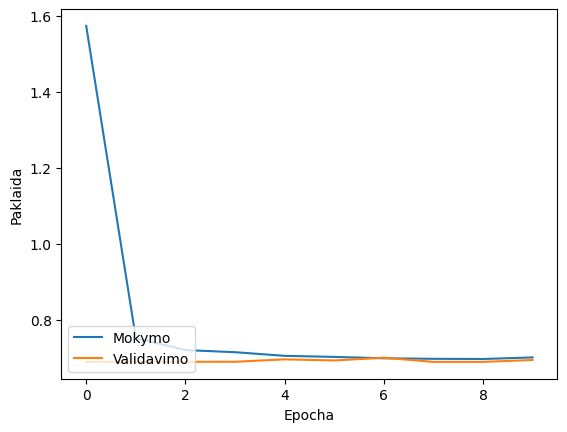

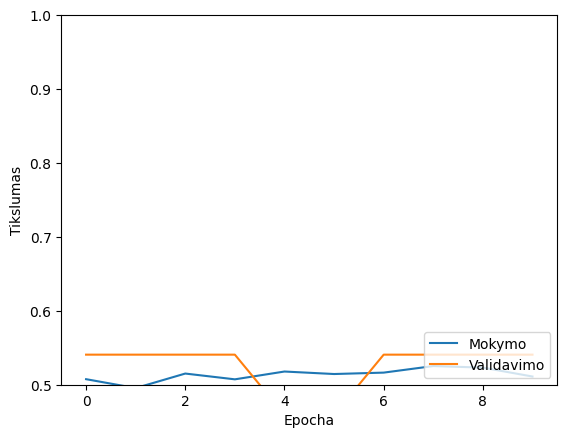

In [ ]:
m7 = create_model3(
    conv_filters=[32, 64, 128, 256],
    activation='sigmoid',
    kernel_sizes=[(3,3), (3,3), (3, 3), (3, 3)],
    pool_sizes=[(2,2), (2,2), (2,2)],
    dense_neurons=[512],
    dropout_rates=[0.6, 0, 0, 0, 0.6],
    optimizer_type='adam',
    learning_rate=0.001,
    loss_type='binary_crossentropy',
    use_batchnorm=False,
    input_shape=(150,150,3)
)
h7 = train_model(m7, train_gen, val_gen, epochs=10)
grafikai(h7)

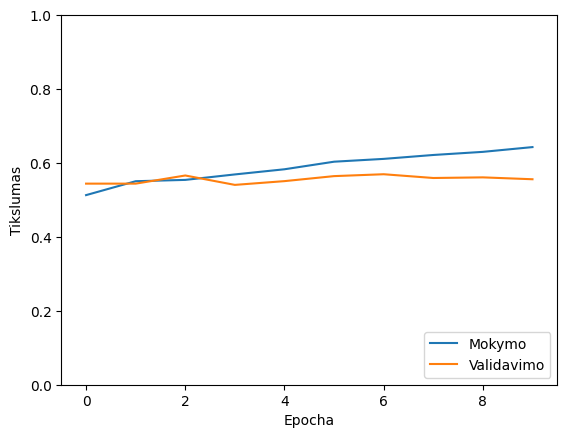

In [ ]:
plt.figure()
plt.plot(h8.history['accuracy'], label='Mokymo')
plt.plot(h8.history['val_accuracy'], label='Validavimo')
plt.xlabel('Epocha')
plt.ylabel('Tikslumas')
plt.ylim([0, 1])
plt.xlim([-0.5, 9.5])
plt.legend(loc='lower right')
plt.show()

Keičiame optimizavimo metodą: Adam, SGD, Adagrad, RMSprop.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 32s 196ms/step - accuracy: 0.4916 - loss: 0.7046 - val_accuracy: 0.5441 - val_loss: 0.6902
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 160ms/step - accuracy: 0.5531 - loss: 0.6909 - val_accuracy: 0.5441 - val_loss: 0.6885
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 167ms/step - accuracy: 0.5475 - loss: 0.6822 - val_accuracy: 0.5661 - val_loss: 0.6871
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 164ms/step - accuracy: 0.5638 - loss: 0.6803 - val_accuracy: 0.5407 - val_loss: 0.6854
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - accuracy: 0.5833 - loss: 0.6717 - val_accuracy: 0.5508 - val_loss: 0.6836
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 179ms/step - accuracy: 0.6057 - loss: 0.6705 - val_accuracy: 0.5644 - val_loss: 0.6806
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 164ms/step - accuracy: 0.6056 - loss: 0.6672 - val_accuracy: 0.5695 - val_loss: 0.6773
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 164ms/step - accuracy: 0.6146 - loss: 0

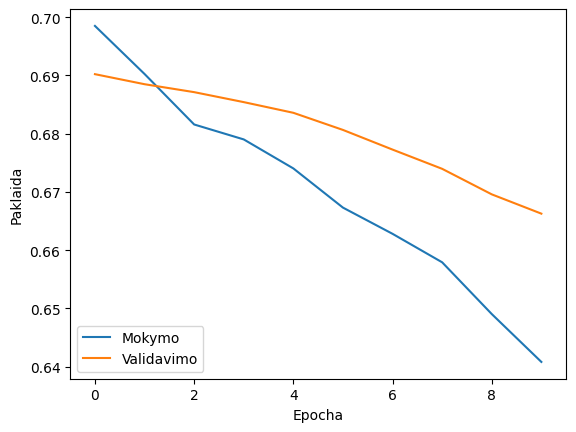

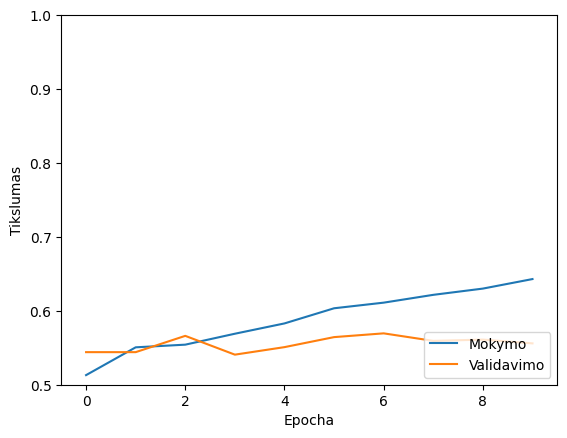

In [ ]:
m8 = create_model3(
    conv_filters=[32, 64, 128, 256],
    activation='relu',
    kernel_sizes=[(3,3), (3,3), (3, 3), (3, 3)],
    pool_sizes=[(2,2), (2,2), (2,2)],
    dense_neurons=[512],
    dropout_rates=[0.6, 0, 0, 0, 0.6],
    optimizer_type='sgd',
    learning_rate=0.001,
    loss_type='binary_crossentropy',
    use_batchnorm=False,
    input_shape=(150,150,3)
)
h8 = train_model(m8, train_gen, val_gen, epochs=10)
grafikai(h8)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 32s 190ms/step - accuracy: 0.5020 - loss: 0.6983 - val_accuracy: 0.5797 - val_loss: 0.6886
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 166ms/step - accuracy: 0.5623 - loss: 0.6825 - val_accuracy: 0.6017 - val_loss: 0.6823
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 162ms/step - accuracy: 0.6176 - loss: 0.6685 - val_accuracy: 0.6068 - val_loss: 0.6708
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 162ms/step - accuracy: 0.6642 - loss: 0.6430 - val_accuracy: 0.6915 - val_loss: 0.6435
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 161ms/step - accuracy: 0.7109 - loss: 0.5921 - val_accuracy: 0.6746 - val_loss: 0.6237
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 162ms/step - accuracy: 0.7310 - loss: 0.5537 - val_accuracy: 0.6898 - val_loss: 0.6037
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 163ms/step - accuracy: 0.7356 - loss: 0.5432 - val_accuracy: 0.7322 - val_loss: 0.5679
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 26s 175ms/step - accuracy: 0.7701 - loss: 0

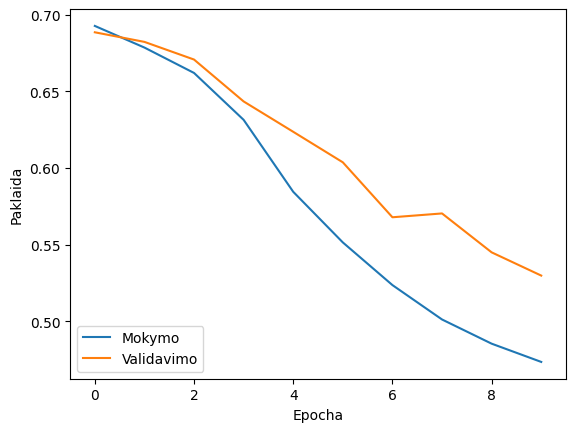

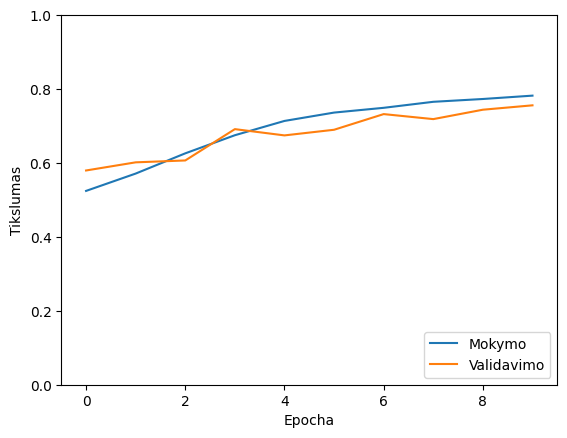

In [ ]:
m9 = create_model3(
    conv_filters=[32, 64, 128, 256],
    activation='relu',
    kernel_sizes=[(3,3), (3,3), (3, 3), (3, 3)],
    pool_sizes=[(2,2), (2,2), (2,2)],
    dense_neurons=[512],
    dropout_rates=[0.6, 0, 0, 0, 0.6],
    optimizer_type='adagrad',
    learning_rate=0.001,
    loss_type='binary_crossentropy',
    use_batchnorm=False,
    input_shape=(150,150,3)
)
h9 = train_model(m9, train_gen, val_gen, epochs=10)
grafikai(h9)

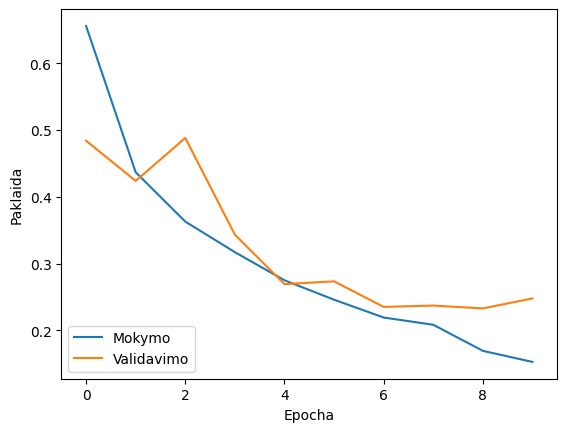

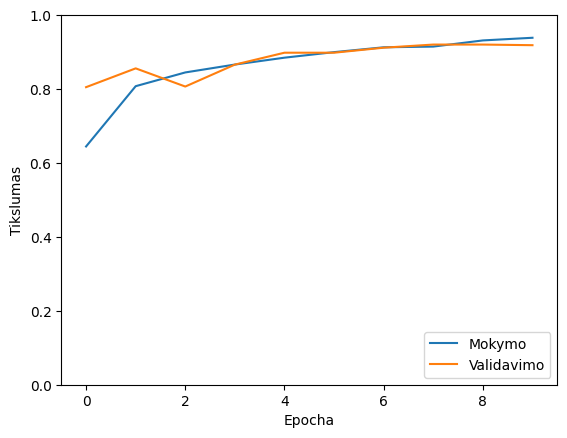

In [ ]:
grafikai(h2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 31s 188ms/step - accuracy: 0.5434 - loss: 1.2913 - val_accuracy: 0.7814 - val_loss: 0.4888
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 25s 167ms/step - accuracy: 0.7735 - loss: 0.4928 - val_accuracy: 0.8068 - val_loss: 0.4378
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 157ms/step - accuracy: 0.8114 - loss: 0.4119 - val_accuracy: 0.8797 - val_loss: 0.3278
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 162ms/step - accuracy: 0.8556 - loss: 0.3438 - val_accuracy: 0.8390 - val_loss: 0.3734
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 159ms/step - accuracy: 0.8709 - loss: 0.3028 - val_accuracy: 0.8186 - val_loss: 0.4443
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 158ms/step - accuracy: 0.8821 - loss: 0.2823 - val_accuracy: 0.8237 - val_loss: 0.4182
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 23s 156ms/step - accuracy: 0.8996 - loss: 0.2351 - val_accuracy: 0.8780 - val_loss: 0.3006
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 24s 160ms/step - accuracy: 0.9135 - loss: 0

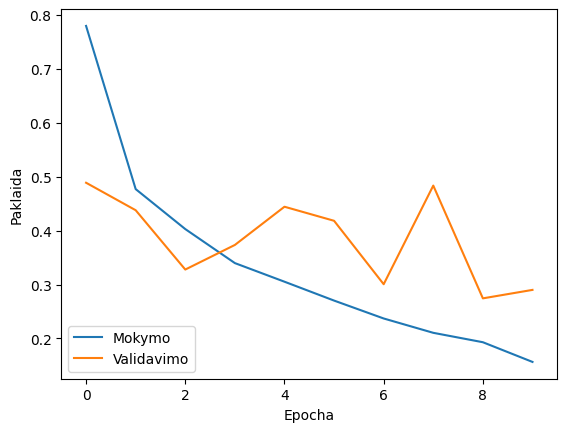

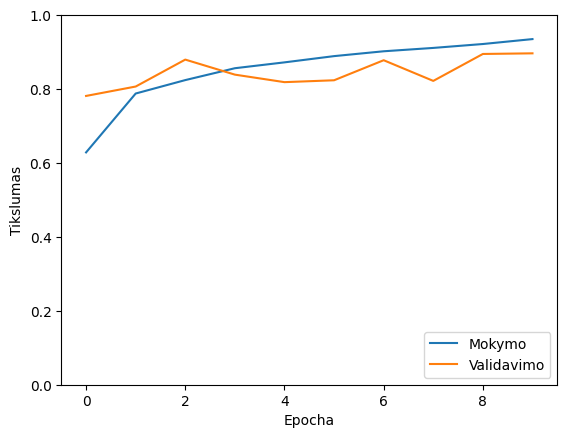

In [ ]:
m10 = create_model3(
    conv_filters=[32, 64, 128, 256],
    activation='relu',
    kernel_sizes=[(3,3), (3,3), (3, 3), (3, 3)],
    pool_sizes=[(2,2), (2,2), (2,2)],
    dense_neurons=[512],
    dropout_rates=[0.6, 0, 0, 0, 0.6],
    optimizer_type='rmsprop',
    learning_rate=0.001,
    loss_type='binary_crossentropy',
    use_batchnorm=False,
    input_shape=(150,150,3)
)
h10 = train_model(m10, train_gen, val_gen, epochs=10)
grafikai(h10)

Testuojamas geriausias variantas (m2).

In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np

def evaluate_model(model, test_gen):
    pred = model.predict(test_gen)

    if pred.shape[1] > 1:
        # multi-class
        y_pred = np.argmax(pred, axis=1)
    else:
        # binary
        y_pred = np.where(pred>0.5, 1, 0).flatten()

    y_true = test_gen.classes
    cm = confusion_matrix(y_true, y_pred)
    return cm, y_true, y_pred


In [16]:
cm, y_true, y_pred = evaluate_model(m2, test_gen)
print(cm)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step
[[312   9]
 [ 76 197]]


Klasifikavio matrica

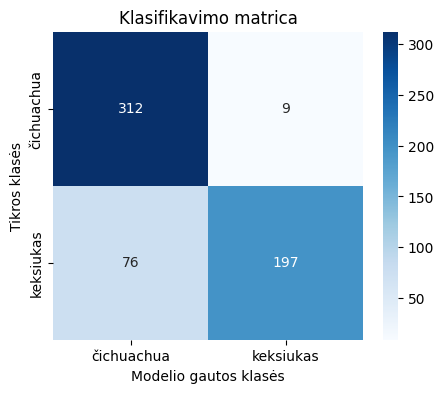

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ['čichuachua', 'keksiukas']
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Tikros klasės')
plt.xlabel('Modelio gautos klasės')
plt.title('Klasifikavimo matrica')
plt.show()


Išsitraukiam 30 reikšmių, jas palyginame su modelio išėjimo reikšmėmis.

In [38]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg


filenames = np.array(test_gen.filenames)
true_labels = np.array(test_gen.classes)

class_indices = test_gen.class_indices
print("Klasės:", class_indices)

sample_indices = []
for cls_name, cls_idx in class_indices.items():
    cls_idxs = np.where(true_labels == cls_idx)[0]      # visi tos klasės paveikslėliai
    np.random.shuffle(cls_idxs)
    sample_indices.extend(cls_idxs[:15])                # pvz., 15 iš kiekvienos klasės

sample_indices = np.array(sample_indices[:30])

# 4. Sudedame į lentelę
results = pd.DataFrame({
    'tikra_klase': true_labels[sample_indices],
    'prognoze': y_pred[sample_indices]
})

print(results.head(30))


Klasės: {'chihuahua': 0, 'muffin': 1}
    tikra_klase  prognoze
0             0         0
1             0         0
2             0         0
3             0         1
4             0         1
5             0         0
6             0         0
7             0         0
8             0         0
9             0         0
10            0         1
11            0         0
12            0         0
13            0         0
14            0         0
15            1         1
16            1         1
17            1         1
18            1         1
19            1         0
20            1         1
21            1         1
22            1         1
23            1         1
24            1         0
25            1         1
26            1         1
27            1         1
28            1         1
29            1         1


Klasifikavimo tikslumas ir paklaida testavimo duomenims.

In [33]:

test_ev = m2.evaluate(test_gen, verbose=2)
print(test_ev)

19/19 - 2s - 122ms/step - accuracy: 0.9040 - loss: 0.2691
[0.26908156275749207, 0.9040403962135315]
